<a href="https://colab.research.google.com/github/Arroyan23/customer-churn-forecast/blob/main/project_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# membaca datanya terlebih dahulu
df = pd.read_csv('train.csv')
print("Berhasil membaca data")

Berhasil membaca data


## memulai proses visualisasi data EDA (Exploratory Data Analytics)
1. Melihat Overview Dari datanya
2. Memulai visualisasi data (mencari korelasi data dan distribusi data)
3. Memulai membuat modelnya

In [2]:
# melihat overview data
my_data_vis = pd.read_csv('train.csv')
my_data_vis.head(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,No
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,No
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,No
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,Yes
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,No


<Axes: title={'center': 'Distribusi Sebaran Data (Perbandingan)'}, xlabel='Churn', ylabel='count'>

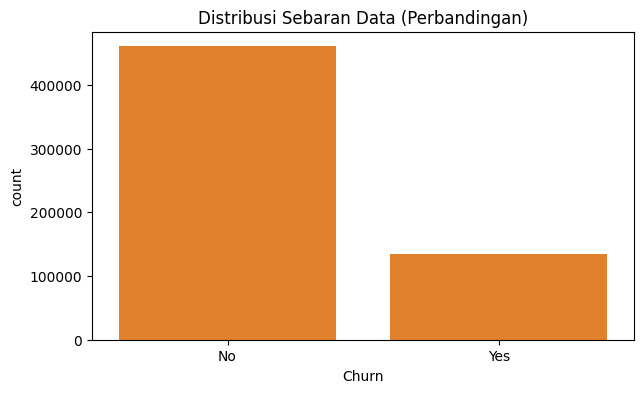

In [3]:
# cek distribusi angka
plt.figure(figsize=(7,4))
sns.countplot(
    data=my_data_vis,
    x='Churn'
)

plt.title("Distribusi Sebaran Data (Perbandingan)")

sns.countplot(
    data=my_data_vis,
    x='Churn',
)

Terlihat di atas bahwa customer churn menunjukkan banyak customer yang tidak balik, ini harus dihandle dengan imbalance sehingga model yang dibuat tidak bias

In [4]:
# mengetahui column nya
# terdapat imbalance class antara yes dan no dimana no lebih banyak daripada yes
my_data_vis.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

<Figure size 700x400 with 0 Axes>

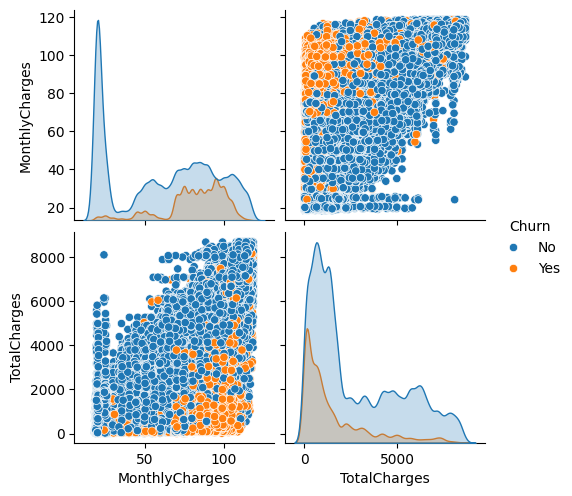

In [5]:
# mengetahui hubungan suatu data numerik dengan data churn (apakah berkorelasi atau tidak)
plt.figure(figsize=(7,4))
sns.pairplot(data=my_data_vis,
    vars=["MonthlyCharges", "TotalCharges"],
    hue="Churn"
)

## Numerical Features VS Churn (Data angka)
mencari pola data yang bentuknya angka kontinu (durasi langganan/tenure dan tagihan)
- Pertanyaan yang berusaha dijawab
apakah orang yang baru langganan sebentar lebih sering berhenti dibanding pelanggan lama

Text(0.5, 1.0, 'Distribusi monthlycharges berdasarkan churn')

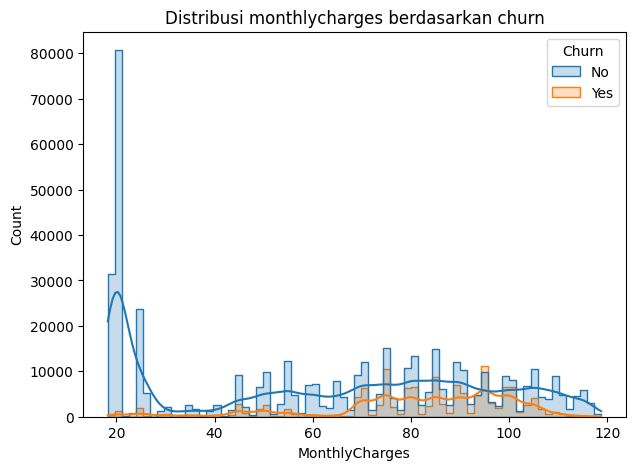

In [6]:
plt.figure(figsize=(7,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, element='step')
plt.title("Distribusi monthlycharges berdasarkan churn")

In [7]:
df.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
display(df.head())

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [12]:
# buat kolom baru
df['Total_Charges'] = df['tenure'] * df['MonthlyCharges']

df.head(10)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total_Charges
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No,1742.90
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No,4031.00
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No,5823.20
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes,69.70
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes,70.45
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,No,20.20
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,No,489.60
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,No,6624.00
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,Yes,79.55
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,No,5502.75


Text(0.5, 1.0, 'hubungan total charges dengan churn')

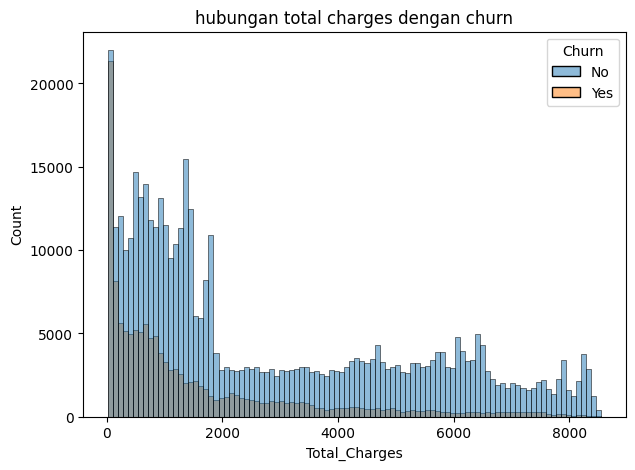

In [13]:
# melihat hubungan total charges dengan churn

plt.figure(figsize=(7,5))
sns.histplot(data=df, x='Total_Charges', hue='Churn')
plt.title("hubungan total charges dengan churn")

## Membuat charge per tenure
Karena TotalCharges adalah perkalian langsung antara masa langganan dan tagihan, sebenarnya angka TotalCharges itu rentan bias oleh durasi langganan (Tenure).Daripada cuma pakai TotalCharges mentah, lu bisa bikin fitur rasio baru:$$\text{Avg\_Monthly\_Paid} = \frac{\text{TotalCharges}}{\text{Tenure}}$$

In [16]:
# membuat rasio baru
df['Avg_Monthly_Paid'] = df['TotalCharges'] / df['tenure']
df.head()
print("the average of the data is :")
df['Avg_Monthly_Paid'].mean()

the average of the data is :


np.float64(66.55983995242147)

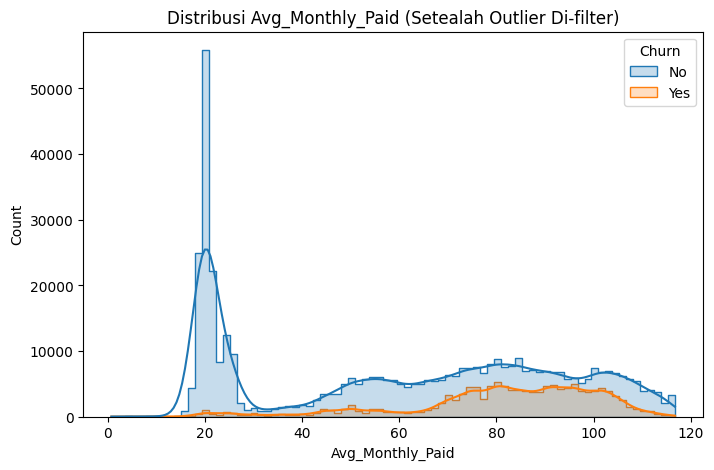

In [20]:
import numpy as np
import pandas as pd

# Trik 1: Ganti tenure 0 jadi 1 (atau filter tenure > 0)
df_clean = df[df['tenure'] > 0].copy()

# Trik 2: Hitung ulang Avg_Monthly_Paid
df_clean['Avg_Monthly_Paid'] = df_clean['TotalCharges'] / df_clean['tenure']

# Trik 3: Tangani jika masih ada outlier ekstrem (misal potong di persentil 99)
q_high = df_clean['Avg_Monthly_Paid'].quantile(0.99)
df_filtered = df_clean[df_clean['Avg_Monthly_Paid'] <= q_high]

# Plot ulang
plt.figure(figsize=(8, 5))
sns.histplot(data=df_filtered, x='Avg_Monthly_Paid', hue='Churn', kde=True, element='step')
plt.title('Distribusi Avg_Monthly_Paid (Setealah Outlier Di-filter)')
plt.show()

In [26]:
df['Avg_Monthly_Paid_Group'] = pd.cut(
    df['Avg_Monthly_Paid'],
    bins=[0,30,90, df['Avg_Monthly_Paid'].max()],
    labels=['Low_Risk', 'Medium_Risk', 'High_Risk']
)

df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Total_Charges,Avg_Monthly_Paid,Avg_Monthly_Paid_Group
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,No,One year,Yes,Mailed check,60.10,1653.85,No,1742.90,57.029310,Medium_Risk
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Two year,No,Credit card (automatic),69.50,3778.20,No,4031.00,65.141379,Medium_Risk
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No,5823.20,100.712931,High_Risk
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes,69.70,70.700000,Medium_Risk
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes,70.45,70.450000,Medium_Risk


## Hitung presentase churn per kelompoknya
Biar makin yakin saat dipresentasikan atau dijadikan laporan, buat tabel proporsi persentase menggunakan `pd.crosstab`

Hasilnya adalah yang tertera dibawah
# kesimpulan
semakin resikonya tinggi karena rata rata tagihan bulanan
maka semakin tinggi juga resiko customer melakukan churn

In [27]:
cross_tab = pd.crosstab(
    df['Avg_Monthly_Paid_Group'],
    df['Churn'],
    normalize='index'
) * 100

print(cross_tab)

# terlihat kalau disini semakin highrisk orang yang batal berlangganan semakin berkurang

Churn                          No        Yes
Avg_Monthly_Paid_Group                      
Low_Risk                97.113753   2.886247
Medium_Risk             73.422874  26.577126
High_Risk               66.775920  33.224080
